# Predictive Maintenance and Maintenance Optimization

## Project Overview

This project aims to predict machine failures using machine learning techniques and optimize maintenance decisions based on predicted failure risks.

The project combines predictive analytics and optimization to support proactive maintenance planning, reduce equipment downtime, and improve maintenance resource allocation.

In [6]:
import pandas as pd

df = pd.read_csv("../data/raw/ai4i2020.csv")


In [7]:
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

(10000, 14)

In [5]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [10]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [11]:
df["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

**Observation:**

The dataset contains 9,661 normal operating observations and 339 machine failure observations.

**Interpretation:**

Machine failures account for approximately 3.39% of all observations, indicating a highly imbalanced classification problem. Special attention will be required during model evaluation because accuracy alone may provide misleading results.

In [12]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


**Observation:**

The dataset contains realistic operating ranges for temperature, rotational speed, torque, and tool wear. Machine failures occur in only 3.39% of observations, confirming a highly imbalanced classification problem.

**Interpretation:**

Several variables, particularly tool wear, rotational speed, and torque, exhibit substantial variation and may play an important role in predicting machine failures. Further exploratory analysis is required to determine how these variables differ between normal and failed machine states.

## Machine Failure Distribution

In [13]:
df["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

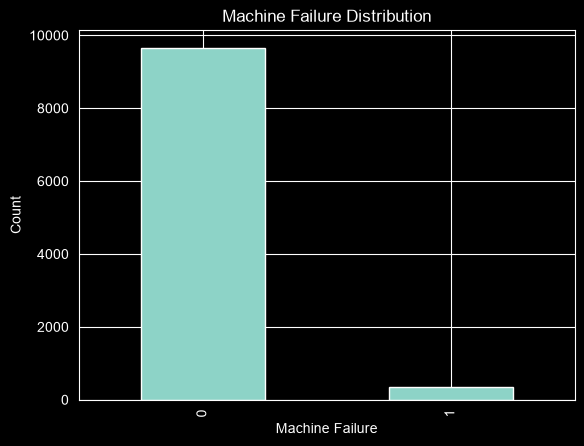

In [17]:
import matplotlib.pyplot as plt

df["Machine failure"].value_counts().plot(kind="bar")

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Count")
plt.savefig("../outputs/figures/01_failure_distribution.png", dpi=300)

plt.show()

**Observation:**

The dataset is highly imbalanced, with 96.61% normal operating observations and only 3.39% machine failure observations.

**Interpretation:**

Class imbalance is a common characteristic of predictive maintenance datasets because machine failures are relatively rare events. As a result, model evaluation should focus on metrics such as precision, recall, F1-score, and ROC-AUC rather than relying solely on accuracy.

## Feature Analysis

In [15]:
df.groupby("Machine failure")["Tool wear [min]"].describe()

,count,mean,std,min,25%,50%,75%,max
Machine failure,,,,,,,,
0,9661.0,106.693717,62.945790,0.0,52.0,107.0,160.0,246.0
1,339.0,143.781711,72.759876,0.0,84.5,165.0,207.5,253.0


**Observation:**

Machines that experienced failure have an average tool wear of 143.78 minutes, compared to 106.69 minutes for machines operating normally.

**Interpretation:**

Failed machines exhibit substantially higher tool wear, suggesting that accumulated wear contributes to increased failure risk. Tool wear is expected to be an important predictor in the machine learning models.

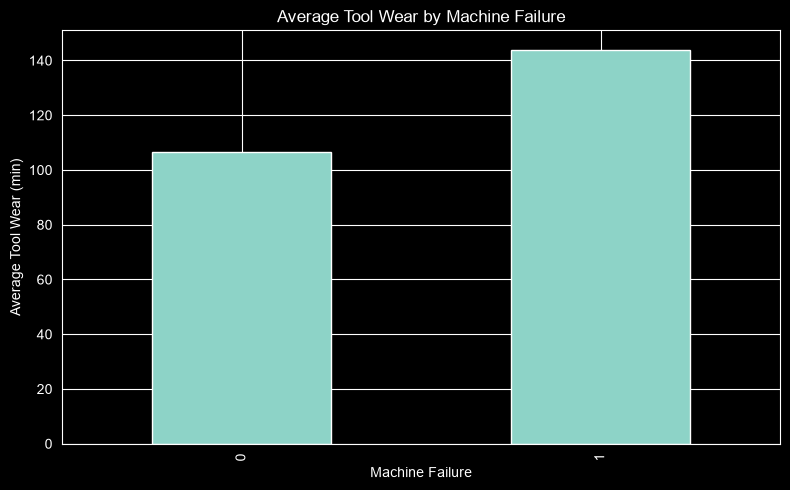

In [18]:
import matplotlib.pyplot as plt

tool_wear_failure = df.groupby("Machine failure")["Tool wear [min]"].mean()

plt.figure(figsize=(8,5))
tool_wear_failure.plot(kind="bar")

plt.title("Average Tool Wear by Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Average Tool Wear (min)")

plt.tight_layout()
plt.savefig("../outputs/figures/02_tool_wear_vs_failure.png", dpi=300)

plt.show()

**Observation:**

Machines that failed have an average tool wear of 143.78 minutes, compared to 106.69 minutes for machines operating normally.

**Interpretation:**

The visualization confirms that failed machines tend to exhibit substantially higher tool wear. This suggests that accumulated wear is an important contributor to machine failure and is likely to be one of the most influential features in the predictive maintenance models.

In [19]:
df.groupby("Machine failure")["Torque [Nm]"].describe()

,count,mean,std,min,25%,50%,75%,max
Machine failure,,,,,,,,
0,9661.0,39.629655,9.472080,12.6,33.10,39.9,46.3,70.0
1,339.0,50.168142,16.374498,3.8,45.95,53.7,61.2,76.6


**Observation:**

Failed machines have an average torque of 50.17 Nm compared to 39.63 Nm for normal machines.

**Interpretation:**

Machines operating under higher mechanical loads are more likely to fail. The substantial increase in average torque among failed machines suggests that mechanical stress is an important contributor to machine failure and may serve as a valuable predictor in the machine learning models.

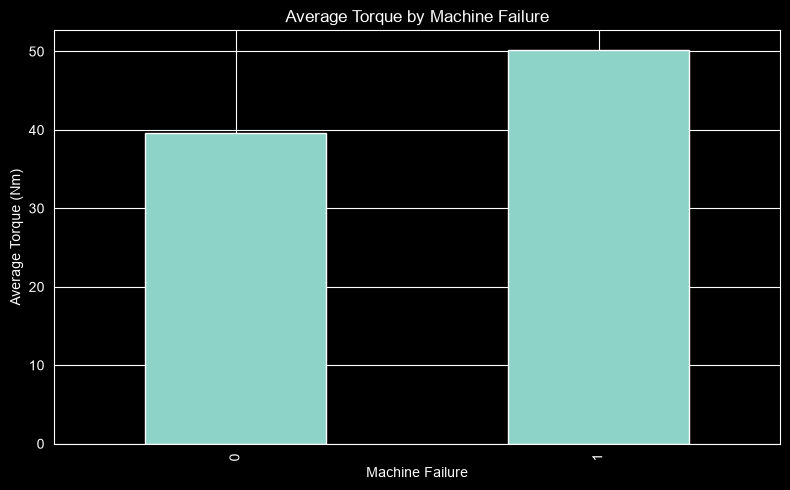

In [20]:
torque_failure = df.groupby("Machine failure")["Torque [Nm]"].mean()

plt.figure(figsize=(8,5))
torque_failure.plot(kind="bar")

plt.title("Average Torque by Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Average Torque (Nm)")

plt.tight_layout()
plt.savefig("../outputs/figures/03_torque_vs_failure.png", dpi=300)

plt.show()

**Observation:**

Failed machines exhibit an average torque of 50.17 Nm, compared to 39.63 Nm for normal machines.

**Interpretation:**

The chart demonstrates that machine failures are associated with higher mechanical loads. Increased torque places greater stress on machine components and appears to contribute to a higher probability of failure.

In [21]:
df.groupby("Machine failure")["Rotational speed [rpm]"].describe()

,count,mean,std,min,25%,50%,75%,max
Machine failure,,,,,,,,
0,9661.0,1540.260014,167.394734,1168.0,1429.0,1507.0,1615.0,2695.0
1,339.0,1496.486726,384.943547,1181.0,1326.5,1365.0,1421.5,2886.0


**Observation:**

Failed machines have an average rotational speed of 1496.49 rpm compared to 1540.26 rpm for normal machines. The failure group also exhibits substantially greater variability in rotational speed.

**Interpretation:**

Unlike tool wear and torque, rotational speed does not appear to have a simple linear relationship with machine failure. The large variability among failed machines suggests that failures may occur under both unusually low and unusually high operating speeds. Further visualization is required to better understand this relationship.

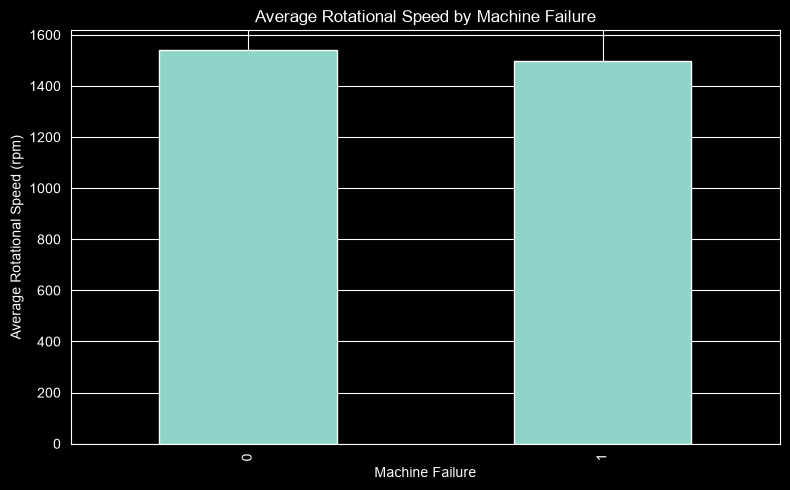

In [22]:
rpm_failure = df.groupby("Machine failure")["Rotational speed [rpm]"].mean()

plt.figure(figsize=(8,5))
rpm_failure.plot(kind="bar")

plt.title("Average Rotational Speed by Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Average Rotational Speed (rpm)")

plt.tight_layout()
plt.savefig("../outputs/figures/04_rpm_vs_failure.png", dpi=300)

plt.show()

**Observation:**

Normal machines operate at an average rotational speed of 1540 rpm, while failed machines operate at an average speed of 1496 rpm. The difference between the groups is relatively small compared to the differences observed for tool wear and torque.

**Interpretation:**

Rotational speed appears to have a weaker direct relationship with machine failure. Nevertheless, the greater variability among failed machines suggests that rotational speed may still provide predictive value when combined with other operational variables.

In [23]:
pd.crosstab(
    df["Type"],
    df["Machine failure"],
    margins=True
)

Machine failure,0,1,All
Type,,,
H,982,21,1003
L,5765,235,6000
M,2914,83,2997
All,9661,339,10000


In [24]:
pd.crosstab(
    df["Type"],
    df["Machine failure"],
    normalize="index"
) * 100

Machine failure,0,1
Type,,
H,97.906281,2.093719
L,96.083333,3.916667
M,97.230564,2.769436


**Observation:**

Failure rates differ across machine types. Low-quality machines (L) exhibit the highest failure rate at 3.92%, while high-quality machines (H) exhibit the lowest failure rate at 2.09%.

**Interpretation:**

Machine quality appears to influence reliability. Lower-quality machines fail more frequently than higher-quality machines, suggesting that machine type contains useful predictive information and should be retained in the modeling process.

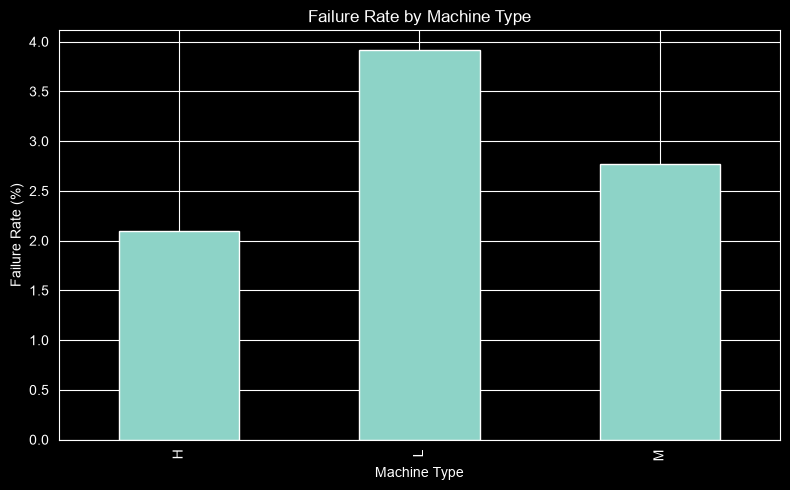

In [25]:
failure_rate = (
    pd.crosstab(
        df["Type"],
        df["Machine failure"],
        normalize="index"
    ) * 100
)[1]

plt.figure(figsize=(8,5))
failure_rate.plot(kind="bar")

plt.title("Failure Rate by Machine Type")
plt.xlabel("Machine Type")
plt.ylabel("Failure Rate (%)")

plt.tight_layout()
plt.savefig("../outputs/figures/05_failure_rate_by_machine_type.png", dpi=300)

plt.show()

**Observation:**

Low-quality machines exhibit the highest failure rate (3.92%), followed by medium-quality machines (2.77%) and high-quality machines (2.09%).

**Interpretation:**

The figure demonstrates a clear relationship between machine quality and reliability. Lower-quality machines are considerably more likely to fail than higher-quality machines, indicating that machine type provides valuable information for failure prediction.

## Temperature Analysis

In [26]:
df.groupby("Machine failure")["Air temperature [K]"].describe()

,count,mean,std,min,25%,50%,75%,max
Machine failure,,,,,,,,
0,9661.0,299.973999,1.990748,295.3,298.3,300.0,301.5,304.5
1,339.0,300.886431,2.071473,295.6,299.1,301.6,302.5,304.4


In [27]:
df.groupby("Machine failure")["Process temperature [K]"].describe()

,count,mean,std,min,25%,50%,75%,max
Machine failure,,,,,,,,
0,9661.0,309.995570,1.486846,305.7,308.8,310.0,311.1,313.8
1,339.0,310.290265,1.363686,306.1,309.5,310.4,311.2,313.7


**Observation:**

Failed machines exhibit slightly higher air and process temperatures than normal machines. The average air temperature increases from 299.97 K to 300.89 K, while the average process temperature increases from 310.00 K to 310.29 K.

**Interpretation:**

Temperature appears to have a modest relationship with machine failure. While failed machines tend to operate at slightly higher temperatures, the differences are relatively small compared to those observed for tool wear and torque. Temperature may contribute to failure prediction but is unlikely to be a primary failure driver.

In [28]:
df.corr(numeric_only=True)["Machine failure"].sort_values(ascending=False)

Machine failure            1.000000
HDF                        0.575800
OSF                        0.531083
PWF                        0.522812
TWF                        0.362904
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
RNF                        0.004516
UDI                       -0.022892
Rotational speed [rpm]    -0.044188
Name: Machine failure, dtype: float64

## Correlation Analysis

**Observation:**

Among the operational variables, torque exhibits the strongest positive correlation with machine failure (0.191), followed by tool wear (0.105) and air temperature (0.083).

The failure-type variables (HDF, OSF, PWF, TWF, RNF) show very high correlations with machine failure because they represent specific failure mechanisms.

**Interpretation:**

Torque and tool wear emerge as the most informative operational predictors of machine failure. The failure-type variables will be excluded from predictive modeling because they are generated as part of the failure outcome and would introduce target leakage.

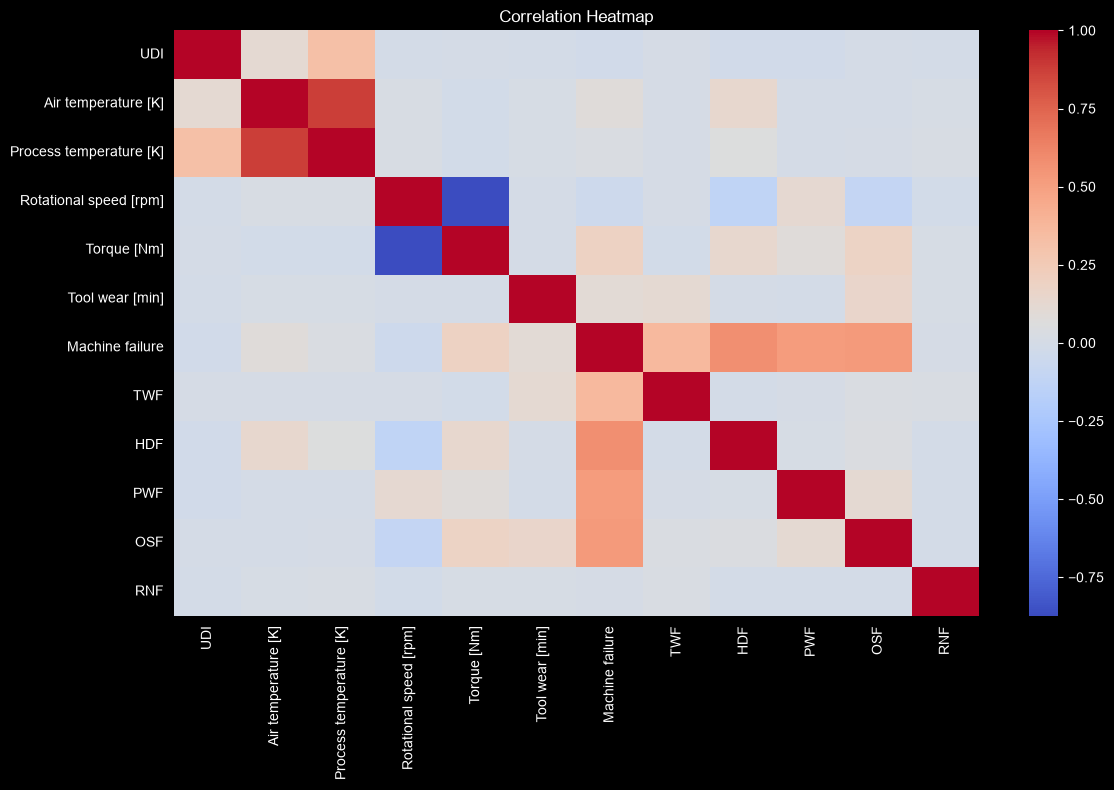

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/06_correlation_heatmap.png",
    dpi=300
)

plt.show()

**Observation:**

The heatmap reveals a strong positive correlation between air temperature and process temperature, as well as a strong negative correlation between rotational speed and torque.

Machine failure exhibits its strongest relationships with torque, tool wear, and the failure-type variables.

**Interpretation:**

The observed correlations are consistent with the engineering characteristics of the system. The strong relationship between rotational speed and torque reflects expected mechanical behavior, while the strong correlations between failure and operational variables support their usefulness for predictive maintenance modeling. Failure-type variables will be excluded from modeling because they introduce target leakage.

## Data Preparation for Machine Learning

In [30]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

In [31]:
df_model = df.drop(
    columns=[
        "UDI",
        "Product ID",
        "TWF",
        "HDF",
        "PWF",
        "OSF",
        "RNF"
    ]
)

df_model.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [32]:
df_model = pd.get_dummies(
    df_model,
    columns=["Type"],
    drop_first=True
)

df_model.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,True,False
2,298.1,308.5,1498,49.4,5,0,True,False
3,298.2,308.6,1433,39.5,7,0,True,False
4,298.2,308.7,1408,40.0,9,0,True,False


In [33]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Air temperature [K]      10000 non-null  float64
 1   Process temperature [K]  10000 non-null  float64
 2   Rotational speed [rpm]   10000 non-null  int64  
 3   Torque [Nm]              10000 non-null  float64
 4   Tool wear [min]          10000 non-null  int64  
 5   Machine failure          10000 non-null  int64  
 6   Type_L                   10000 non-null  bool   
 7   Type_M                   10000 non-null  bool   
dtypes: bool(2), float64(3), int64(3)
memory usage: 488.4 KB


In [34]:
df_model.shape

(10000, 8)

### Feature Selection

The following variables were removed before modeling:

- UDI
- Product ID
- TWF
- HDF
- PWF
- OSF
- RNF

The identifier variables were removed because they do not contain predictive information. The failure-type variables were removed to prevent target leakage.

The categorical machine type variable was encoded using one-hot encoding for use in machine learning models.

## Train-Test Split

In [38]:
from sklearn.model_selection import train_test_split

X = df_model.drop("Machine failure", axis=1)
y = df_model["Machine failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)
print(y_train.value_counts(normalize=True) * 100)
print(y_test.value_counts(normalize=True) * 100)

X_train: (8000, 7)
X_test : (2000, 7)
y_train: (8000,)
y_test : (2000,)
Machine failure
0    96.6125
1     3.3875
Name: proportion, dtype: float64
Machine failure
0    96.6
1     3.4
Name: proportion, dtype: float64


### Train-Test Split

The dataset was divided into training and testing subsets using an 80/20 split.

Stratified sampling was applied to preserve the original failure rate distribution across both subsets due to the highly imbalanced nature of the target variable.

**Observation:**

The training and testing datasets preserve the original class distribution of approximately 96.6% normal observations and 3.4% failure observations.

**Interpretation:**

The stratified train-test split successfully maintained the target variable distribution across both subsets. This ensures that model training and evaluation are performed under representative operating conditions.

## Baseline Classification Model

In [39]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [40]:
y_pred = dt_model.predict(X_test)

In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.978
Precision: 0.6818181818181818
Recall   : 0.6617647058823529
F1 Score : 0.6716417910447762


### Decision Tree Results

| Metric | Value |
|----------|----------:|
| Accuracy | 97.8% |
| Precision | 68.2% |
| Recall | 66.2% |
| F1 Score | 67.2% |

**Observation:**

The Decision Tree classifier achieved strong overall performance and successfully identified many machine failures despite the highly imbalanced dataset.

**Interpretation:**

The model demonstrates that operational variables contain meaningful predictive information. However, approximately one-third of actual failures remain undetected, indicating room for improvement through more advanced machine learning models.

## Random Forest Classifier

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [43]:
y_pred_rf = rf_model.predict(X_test)

In [44]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.9815
Precision: 0.8780487804878049
Recall   : 0.5294117647058824
F1 Score : 0.6605504587155964


### Random Forest Results

| Metric | Value |
|----------|----------:|
| Accuracy | 98.15% |
| Precision | 87.80% |
| Recall | 52.94% |
| F1 Score | 66.06% |

**Observation:**

The Random Forest model achieved higher accuracy and substantially higher precision than the Decision Tree model. However, recall decreased considerably.

**Interpretation:**

The Random Forest classifier is more conservative when predicting failures, resulting in fewer false alarms but also more missed failures. In predictive maintenance applications, recall is particularly important because undetected failures can lead to costly downtime.

In [45]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

print(cm)

[[1927    5]
 [  32   36]]


### Random Forest Confusion Matrix

| Actual / Predicted | Normal | Failure |
|--------------------|--------|----------|
| Normal | 1927 | 5 |
| Failure | 32 | 36 |

**Observation:**

The model correctly identified 36 machine failures while missing 32 failures. Only 5 normal observations were incorrectly classified as failures.

**Interpretation:**

The Random Forest model is highly precise when predicting failures, producing very few false alarms. However, the model misses nearly half of all actual failures, which may limit its usefulness in predictive maintenance scenarios where detecting failures is a priority.

In [46]:
RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [47]:
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_balanced.fit(X_train, y_train)

y_pred_balanced = rf_balanced.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_balanced))
print("Precision:", precision_score(y_test, y_pred_balanced))
print("Recall   :", recall_score(y_test, y_pred_balanced))
print("F1 Score :", f1_score(y_test, y_pred_balanced))

Accuracy : 0.981
Precision: 0.734375
Recall   : 0.6911764705882353
F1 Score : 0.7121212121212122


In [48]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_balanced))

[[1915   17]
 [  21   47]]


### Balanced Random Forest Results

| Metric | Value |
|----------|----------:|
| Accuracy | 98.10% |
| Precision | 73.44% |
| Recall | 69.12% |
| F1 Score | 71.21% |

**Observation:**

Applying class balancing improved the model's ability to detect machine failures. Recall increased from 52.94% to 69.12%, while F1-score improved from 66.06% to 71.21%.

**Interpretation:**

The balanced Random Forest model provides a more suitable tradeoff for predictive maintenance applications. Although precision decreased slightly, the model detects substantially more failures while maintaining strong overall performance.